<a href="https://colab.research.google.com/github/BegoAN/IMAGES_IA_/blob/main/DETECTAR_CARAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Guía Rápida sobre Preprocesamiento de Imágenes Faciales para Redes Neuronales usando OpenCV en Python**

https://medium.com/metadatos/gu%C3%ADa-r%C3%A1pida-sobre-preprocesamiento-de-im%C3%A1genes-faciales-para-redes-neuronales-usando-opencv-en-c68599ca08dd



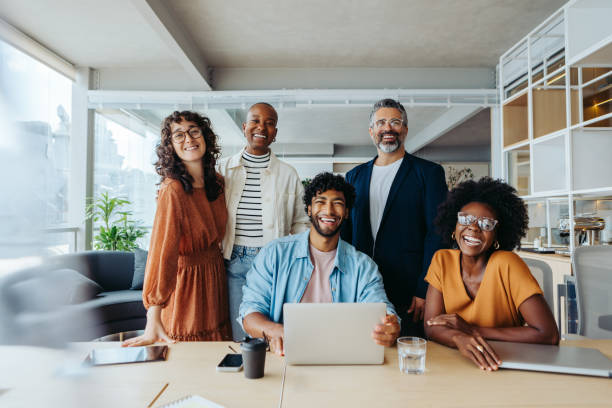

In [ ]:
import cv2
from google.colab.patches import cv2_imshow

# Removed trailing space from the image path
img = cv2.imread('/home/gente.jpg', cv2.IMREAD_COLOR)
cv2_imshow(img)

OBTENER LAS DIMENSIONES

In [ ]:
# Obtener las dimensiones
alto, ancho, numero_canales = img.shape

print("Alto:", alto)
print("Ancho:", ancho)
print("Número de canales:", numero_canales)

Alto: 408
Ancho: 612
Número de canales: 3


En OpenCV, la imagen se carga en orden BGR:

*   img[:, :, 0] → azul
*   img[:, :, 1] → verde
*   img[:, :, 2] → rojo

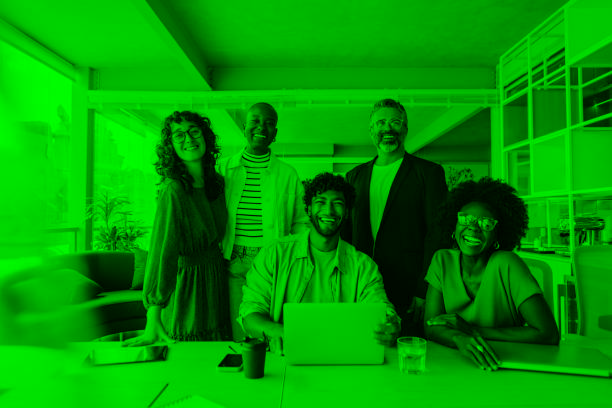

In [ ]:
# Para dejar únicamente el verde:
imagen_verde = img.copy()

imagen_verde[:, :, 0] = 0  # Eliminar azul
imagen_verde[:, :, 2] = 0  # Eliminar rojo

cv2_imshow(imagen_verde)

VERSIÓN EN ESCALA DE GRISES

Para evitar distracciones en la clasificación de imágenes faciales, puede ser una buena idea usar imágenes en blanco y negro (o tal vez no, siempre puedes probar las dos versiones)

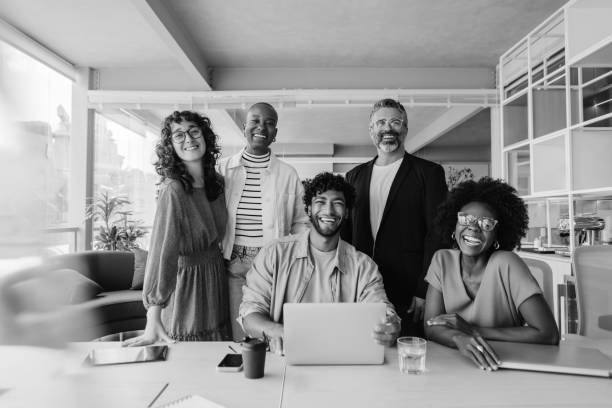

In [ ]:
imagen_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
cv2_imshow(imagen_gris)

**DETECCIÓN DE ROSTRO Y OJOS**

Con el método del archivo de esta biblioteca sí necesito un archivo XML, pero hay aternativas, la siguiente la ha generado la IA

In [ ]:
!pip install mtcnn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 59.9 MB/s eta 0:00:00


In [ ]:
from mtcnn import MTCNN
from mtcnn.utils.images import load_image

# Cargar la imagen JPG
imagen = load_image("/home/gente.jpg")

# Crear el detector
detector = MTCNN()

# Buscar rostros
rostros = detector.detect_faces(imagen)

# Mostrar el resultado
if len(rostros) > 0:
    print("⚠️ Se han detectado rostros:", len(rostros))
else:
    print("No se han detectado rostros")

⚠️ Se han detectado rostros: 5


**detect_faces()** solo detecta los rostros y devuelve sus posiciones; no dibuja los rectángulos automáticamente. Hay que añadir unas líneas para mostrarlos.

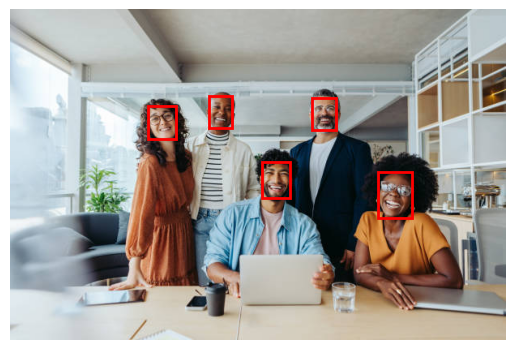

Rostros detectados: 5


In [ ]:
from mtcnn import MTCNN
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Cargar la imagen JPG
imagen = np.array(Image.open("/home/gente.jpg").convert("RGB"))

# Detectar rostros
detector = MTCNN()
rostros = detector.detect_faces(imagen)

# Mostrar la imagen
figura, eje = plt.subplots()
eje.imshow(imagen)

# Dibujar un rectángulo en cada rostro
for rostro in rostros:
    x, y, ancho, alto = rostro["box"]

    rectangulo = Rectangle(
        (x, y),
        ancho,
        alto,
        fill=False,
        edgecolor="red",
        linewidth=2
    )

    eje.add_patch(rectangulo)

eje.axis("off")
plt.show()

print("Rostros detectados:", len(rostros))

como ya tengo los rostros detectados, ahora es más fácil detectar los ojos

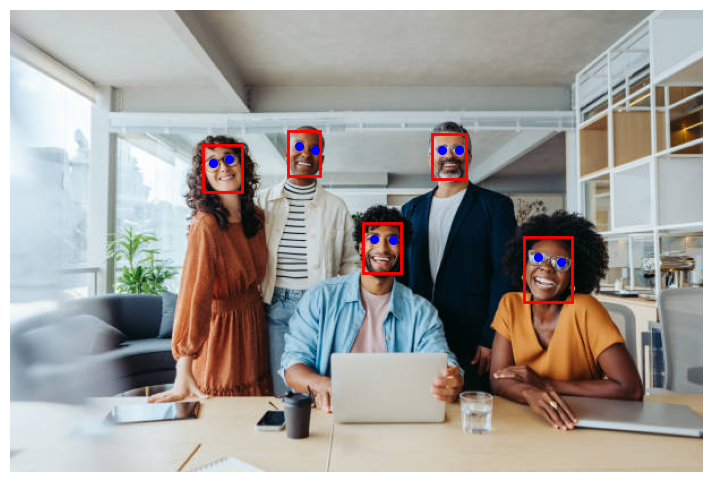

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Crear una nueva figura y mostrar la imagen
figura, eje = plt.subplots(figsize=(10, 6))
eje.imshow(imagen)

for rostro in rostros:
    x, y, ancho, alto = rostro["box"]

    # Dibujar el rectángulo rojo del rostro
    rectangulo = Rectangle(
        (x, y),
        ancho,
        alto,
        fill=False,
        edgecolor="red",
        linewidth=2
    )

    eje.add_patch(rectangulo)

    # Obtener las coordenadas de los ojos
    ojo_izquierdo = rostro["keypoints"]["left_eye"]
    ojo_derecho = rostro["keypoints"]["right_eye"]

    # Dibujar los ojos como puntos azules
    eje.scatter(
        ojo_izquierdo[0],
        ojo_izquierdo[1],
        color="blue",
        s=30
    )

    eje.scatter(
        ojo_derecho[0],
        ojo_derecho[1],
        color="blue",
        s=30
    )

eje.axis("off")
plt.show()

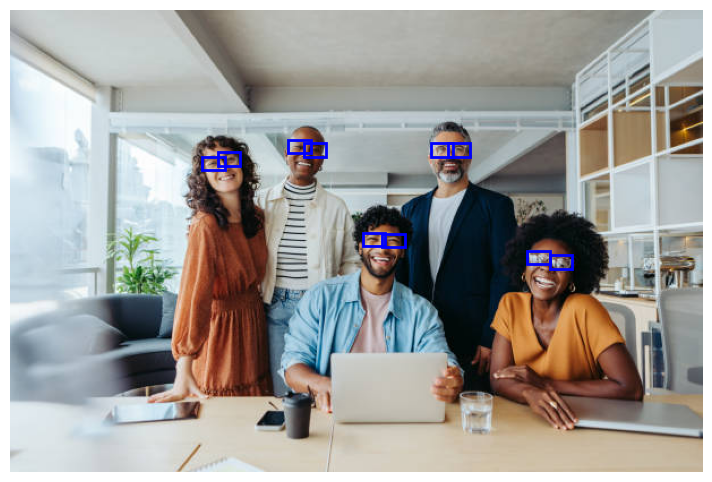

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

plt.figure(figsize=(10, 6))
plt.imshow(imagen)

for rostro in rostros:
    ojo_izquierdo = rostro["keypoints"]["left_eye"]
    ojo_derecho = rostro["keypoints"]["right_eye"]

    for ojo in [ojo_izquierdo, ojo_derecho]:
        x, y = ojo

        rectangulo = Rectangle(
            (x - 10, y - 6),
            20,
            12,
            fill=False,
            edgecolor="blue",
            linewidth=2
        )

        plt.gca().add_patch(rectangulo)

plt.axis("off")
plt.show()

**RECORTAR CARAS**

La línea principal es:


*   cara_recortada = imagen[y:y + alto, x:x + ancho]




*RECORTAR LA PRIMERA CARA (IA)*

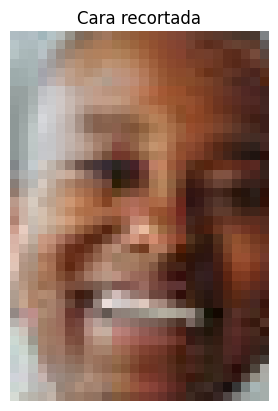

In [ ]:
import matplotlib.pyplot as plt

# Coordenadas de la primera cara detectada
x, y, ancho, alto = rostros[0]["box"]

# Evitar coordenadas negativas
x = max(0, x)
y = max(0, y)

# Recortar la cara
cara_recortada = imagen[y:y + alto, x:x + ancho]

# Mostrar el recorte
plt.imshow(cara_recortada)
plt.axis("off")
plt.title("Cara recortada")
plt.show()

*PARA RECORTAR TODAS LAS CARAS (IA)*

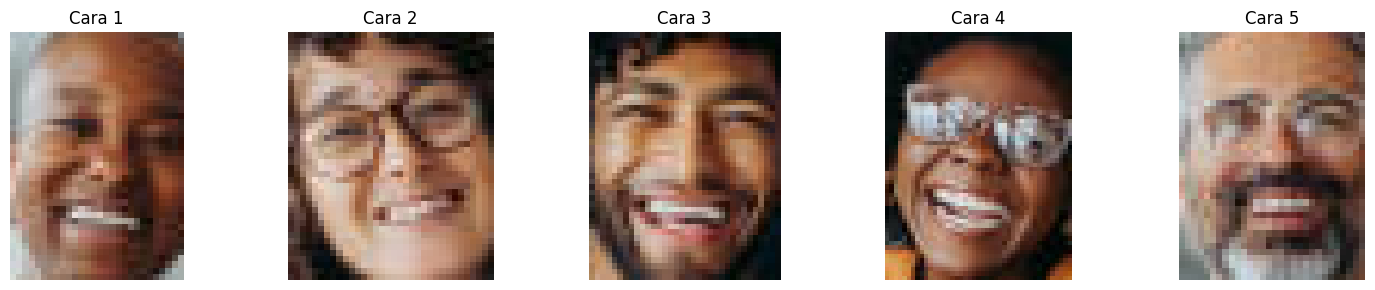

In [ ]:
import matplotlib.pyplot as plt

caras_recortadas = []

# Recortar todas las caras detectadas
for rostro in rostros:
    x, y, ancho, alto = rostro["box"]

    x = max(0, x)
    y = max(0, y)

    cara = imagen[y:y + alto, x:x + ancho]
    caras_recortadas.append(cara)

# Mostrar todas las caras en una fila
figura, ejes = plt.subplots(
    1,
    len(caras_recortadas),
    figsize=(3 * len(caras_recortadas), 3)
)

# Evitar errores si solo se detecta una cara
if len(caras_recortadas) == 1:
    ejes = [ejes]

for i, cara in enumerate(caras_recortadas):
    ejes[i].imshow(cara)
    ejes[i].set_title(f"Cara {i + 1}")
    ejes[i].axis("off")

plt.tight_layout()
plt.show()

**Redimensionamiento de imágenes**


Las redes neuronales necesitan que todas las imágenes de entrada tengan la misma forma y tamaño, ya que la GPU aplicará la misma instrucción a un lote de imágenes al mismo tiempo para lograr ser súper rápida.

In [ ]:
from PIL import Image
import numpy as np

caras_redimensionadas = []

for cara in caras_recortadas:

    # Convertir el array en imagen
    cara_pil = Image.fromarray(cara)

    # Redimensionar a 224 x 224 píxeles
    cara_pil = cara_pil.resize((224, 224))

    # Volver a convertirla en array
    cara_array = np.array(cara_pil)

    # Normalizar los píxeles de 0-255 a 0-1
    cara_array = cara_array / 255.0

    # Guardar la cara preparada
    caras_redimensionadas.append(cara_array)

# Convertir la lista completa en un único array
caras_redimensionadas = np.array(caras_redimensionadas)

print("Dimensiones finales:", caras_redimensionadas.shape)

Dimensiones finales: (5, 224, 224, 3)


Para ver las caras redimensionadas

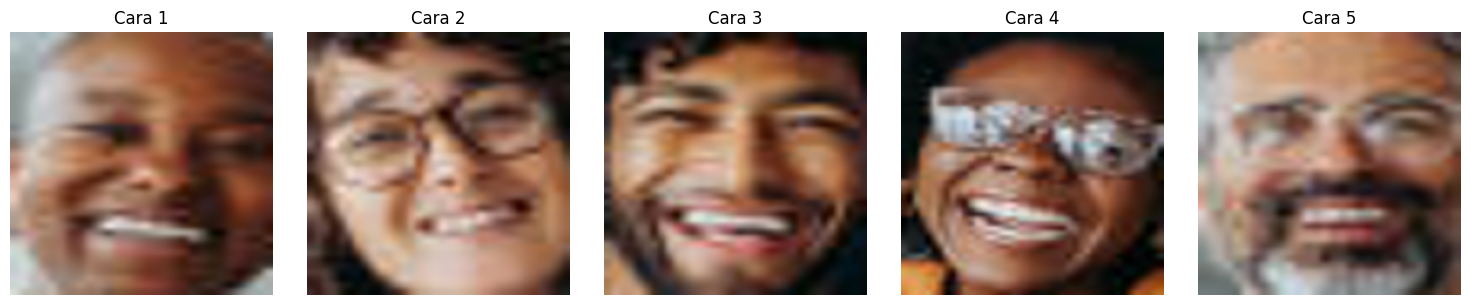

In [ ]:
import matplotlib.pyplot as plt

figura, ejes = plt.subplots(
    1,
    len(caras_redimensionadas),
    figsize=(3 * len(caras_redimensionadas), 3)
)

if len(caras_redimensionadas) == 1:
    ejes = [ejes]

for i, cara in enumerate(caras_redimensionadas):
    ejes[i].imshow(cara)
    ejes[i].set_title(f"Cara {i + 1}")
    ejes[i].axis("off")

plt.tight_layout()
plt.show()

La variable que después utilizarías como entrada de la red neuronal sería:

*   caras_redimensionadas



**NORMALIZACIÓN**

una normalización visual con el fin de corregir imágenes demasiado oscuras o excesivamente claras; e incluso se puede corregir el bajo contraste.

Para una red neuronal, la forma más sencilla es dividir los píxeles entre 255, pero ya lo aplique antes y no debo volver a aplicarlos:

*   imagen_normalizada = imagen.astype("float32") / 255.0




Para todas las caras redimensionadas:

*   caras_normalizadas = caras_redimensionadas.astype("float32") / 255.0
*  print("Valor mínimo:", caras_normalizadas.min())
*   print("Valor máximo:", caras_normalizadas.max())




In [ ]:
print(caras_normalizadas.min())
print(caras_normalizadas.max())

0.0
0.003921569


arreglo porque había normalizado dos veces:

In [ ]:
caras_normalizadas = caras_normalizadas * 255.0

print("Mínimo:", caras_normalizadas.min())
print("Máximo:", caras_normalizadas.max())

Mínimo: 0.0
Máximo: 1.0


Y después normaliza una sola vez:

In [ ]:
caras_redimensionadas = np.array(caras_redimensionadas)

caras_normalizadas = caras_redimensionadas / 255.0